<a href="https://colab.research.google.com/github/JorgeCaldeira/Beware-the-dog/blob/main/DL_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##TODO
Please add max 2 pages to the report of Milestone 0 with:

*   data pipeline, including preprocessing
baseline description:

    *  model name / architecture depth;
    *  input shape;
    *  loss;
    *  optimiser;
    *  training budget (epochs, LR, batch, GPU time)


* preliminary results and training curves
* known issues and next steps, including a detailed plan for the rest of the experiments






By the first milestone, it is expected that you have the data downloaded and ready to be used, the models clearly identified and a skeleton code to start working on.

This time, the document should be 3 pages max and it can include whatever is still relevant from the proposal. It should have:
* Title, group members
* Introduction: this section introduces your problem, and the overall plan for approaching your problem
* Problem statement: Describe your problem precisely specifying the dataset to be used, expected results and evaluation
* Technical Approach: Describe the methods you intend to apply to solve the given problem
* Figure describing the approach / methodology.

Get inspiration from the papers that you’re reading for your project. Some examples:
figure 1 of this paper or similar
check the posters here or go check LASIGE posters in C6 floor 2.
Describe the experiments you are planning to do and preliminary results if you have them.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import os

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#for root, dirs, files in os.walk('/content/drive'):
#    if 'dog-breed-identification' in root:
#        print(root)

In [4]:
import os
os.chdir('/content/drive/MyDrive/AP Projeto/dog-breed-identification')

In [5]:
#!ls "/content/drive/MyDrive/AP Projeto/dog-breed-identification/"

In [6]:
#!zip -r train.zip train

In [7]:
!cp "/content/drive/MyDrive/AP Projeto/dog-breed-identification/train.zip" /content/train.zip
!unzip -q /content/train.zip -d /content/train_local

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score


labels_df = pd.read_csv('labels.csv')
breed_list = sorted(labels_df['breed'].unique())
breed_to_idx = {breed: i for i, breed in enumerate(breed_list)}
train_df, val_df = train_test_split(labels_df, test_size=0.2, random_state=42, stratify=labels_df['breed'])

class DogDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_id = self.dataframe.iloc[idx, 0]
        breed_name = self.dataframe.iloc[idx, 1]
        label = breed_to_idx[breed_name]

        img_path = os.path.join(self.img_dir, f"{img_id}.jpg")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

Augmentation e baseline transforms

In [9]:
imagenet_normalization = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

baseline_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    imagenet_normalization
])

augmented_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(45),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    imagenet_normalization
])

Funcao para validar o modelo

In [10]:
def validate_model(model, loader, criterion, device):
    model.eval()
    val_loss = 0.0
    correct_top1 = 0
    correct_top5 = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            total += labels.size(0)

            # Top-1 Accuracy
            _, predicted = outputs.max(1)
            correct_top1 += predicted.eq(labels).sum().item()

            # Top-5 Accuracy
            _, top5_preds = outputs.topk(5, 1, True, True)
            correct_top5 += top5_preds.eq(labels.view(-1, 1).expand_as(top5_preds)).sum().item()

            # F1
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = val_loss / total
    acc_top1 = 100. * correct_top1 / total
    acc_top5 = 100. * correct_top5 / total
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, acc_top1, acc_top5, macro_f1

In [11]:
def initialize_model():
    model = models.resnet50(weights='DEFAULT') # slides dizem para usarmos uma pre treinada ja (semana 4 acho eu)

    for param in model.parameters():
        param.requires_grad = False

    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 120)

    return model

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_hits = 0
    total_samples = 0

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()

        predictions = model(images)
        loss = criterion(predictions, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted_class = predictions.max(1)
        total_samples += targets.size(0)
        correct_hits += predicted_class.eq(targets).sum().item()

    return running_loss / total_samples, 100. * correct_hits / total_samples

COM AUGMENTED:

usamos o train de augmented para treinar assim e o val usamos o baseline(para testar se aprendeu caracteriristicas ou decorou coisas)

Using: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 152MB/s]


Epoch 1/5:
  [TRAIN] Loss: 4.5679 | Acc: 10.64%
  [VALID] Loss: 4.2657 | Top-1: 35.70% | Top-5: 70.56% | F1: 0.3175
------------------------------
Epoch 2/5:
  [TRAIN] Loss: 4.1453 | Acc: 32.66%
  [VALID] Loss: 3.8451 | Top-1: 56.33% | Top-5: 87.19% | F1: 0.5264
------------------------------
Epoch 3/5:
  [TRAIN] Loss: 3.7987 | Acc: 43.94%
  [VALID] Loss: 3.4386 | Top-1: 66.21% | Top-5: 92.76% | F1: 0.6387
------------------------------
Epoch 4/5:
  [TRAIN] Loss: 3.5081 | Acc: 49.36%
  [VALID] Loss: 3.1455 | Top-1: 70.32% | Top-5: 93.94% | F1: 0.6802
------------------------------
Epoch 5/5:
  [TRAIN] Loss: 3.2656 | Acc: 51.58%
  [VALID] Loss: 2.8616 | Top-1: 73.15% | Top-5: 95.01% | F1: 0.7118
------------------------------


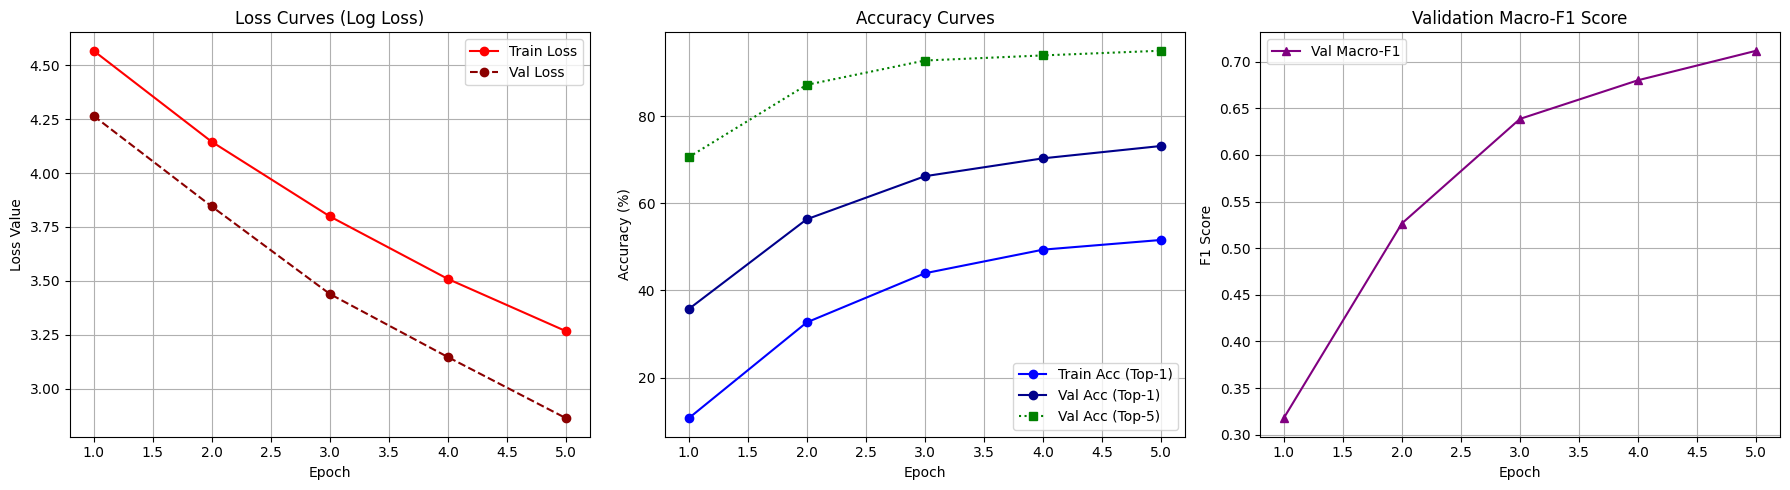

In [12]:
train_set = DogDataset(train_df, '/content/train_local/train/', transform=augmented_transform)
val_set = DogDataset(val_df, '/content/train_local/train/', transform=baseline_transform)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2, pin_memory=True) # pin memory e num_workers deixa um bocado mais rapido
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # para usar o t4 do colab
print(f"Using: {device}")

train_losses, val_losses = [], []
train_accs, val_accs_top1, val_accs_top5 = [], [], []
val_f1_history = []

dog_model = initialize_model().to(device)
criterion = nn.CrossEntropyLoss() # na semana 3 isto é mencionado
optimizer = optim.Adam(dog_model.fc.parameters(), lr=0.0001)

num_epochs = 5

for epoch in range(num_epochs):
    t_loss, t_acc = train_epoch(dog_model, train_loader, criterion, optimizer, device) # treinar
    v_loss, v_top1, v_top5, v_f1 = validate_model(dog_model, val_loader, criterion, device) #validar

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    train_accs.append(t_acc)
    val_accs_top1.append(v_top1)
    val_accs_top5.append(v_top5)
    val_f1_history.append(v_f1)

    print(f"Epoch {epoch+1}/{num_epochs}:")
    print(f"  [TRAIN] Loss: {t_loss:.4f} | Acc: {t_acc:.2f}%")
    print(f"  [VALID] Loss: {v_loss:.4f} | Top-1: {v_top1:.2f}% | Top-5: {v_top5:.2f}% | F1: {v_f1:.4f}")
    print("-" * 30)

#FAZER PLOTS PARA TREINO E TEST (Baseline)
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', marker='o', color='red')
plt.plot(range(1, num_epochs + 1), val_losses, label='Val Loss', marker='o', linestyle='--', color='darkred')
plt.title('Loss Curves (Log Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(range(1, num_epochs + 1), train_accs, label='Train Acc (Top-1)', marker='o', color='blue')
plt.plot(range(1, num_epochs + 1), val_accs_top1, label='Val Acc (Top-1)', marker='o', color='darkblue')
plt.plot(range(1, num_epochs + 1), val_accs_top5, label='Val Acc (Top-5)', marker='s', linestyle=':', color='green')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(range(1, num_epochs + 1), val_f1_history, label='Val Macro-F1', marker='^', color='purple')
plt.title('Validation Macro-F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
# Limpar memorias e wtv para nao dar problemas de out of memory ehntre os dois
import gc

del dog_model
del optimizer
torch.cuda.empty_cache()
gc.collect()

11214

USING BASELINE

Epoch 1/5:
  [TRAIN] Loss: 4.4334 | Acc: 19.10%
  [VALID] Loss: 4.1034 | Top-1: 44.35% | Top-5: 79.46% | F1: 0.4074
------------------------------
Epoch 2/5:
  [TRAIN] Loss: 3.7308 | Acc: 56.77%
  [VALID] Loss: 3.5613 | Top-1: 66.85% | Top-5: 93.74% | F1: 0.6504
------------------------------
Epoch 3/5:
  [TRAIN] Loss: 3.1589 | Acc: 73.22%
  [VALID] Loss: 3.0865 | Top-1: 71.00% | Top-5: 95.16% | F1: 0.6930
------------------------------
Epoch 4/5:
  [TRAIN] Loss: 2.6763 | Acc: 79.65%
  [VALID] Loss: 2.6819 | Top-1: 74.82% | Top-5: 96.38% | F1: 0.7333
------------------------------
Epoch 5/5:
  [TRAIN] Loss: 2.2749 | Acc: 83.18%
  [VALID] Loss: 2.3650 | Top-1: 78.53% | Top-5: 97.11% | F1: 0.7721
------------------------------


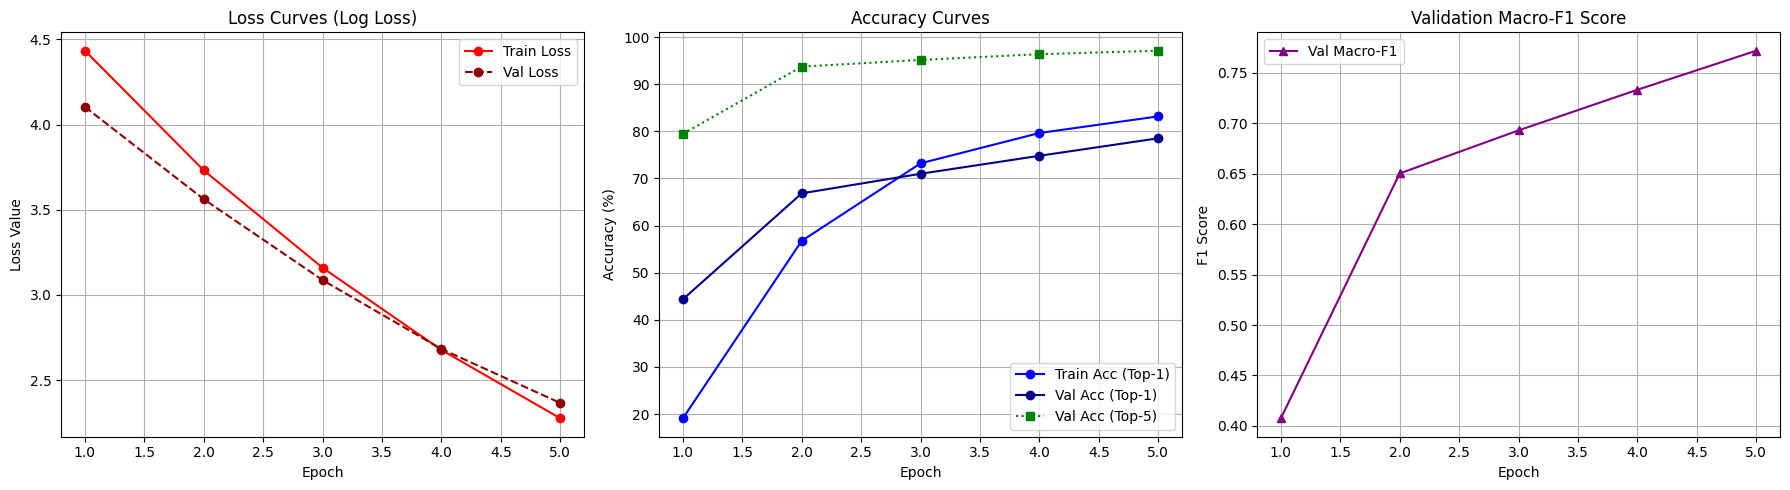

In [14]:
train_set = DogDataset(train_df, '/content/train_local/train/', transform=baseline_transform)
val_set = DogDataset(val_df, '/content/train_local/train/', transform=baseline_transform)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2, pin_memory=True) # pin memory e num_workers deixa um bocado mais rapido
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # para usar o t4 do colab

train_losses, val_losses = [], []
train_accs, val_accs_top1, val_accs_top5 = [], [], []
val_f1_history = []

dog_model = initialize_model().to(device)
criterion = nn.CrossEntropyLoss() # na semana 3 isto é mencionado
optimizer = optim.Adam(dog_model.fc.parameters(), lr=0.0001)

num_epochs = 5

for epoch in range(num_epochs):
    t_loss, t_acc = train_epoch(dog_model, train_loader, criterion, optimizer, device) # treinar
    v_loss, v_top1, v_top5, v_f1 = validate_model(dog_model, val_loader, criterion, device) #validar

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    train_accs.append(t_acc)
    val_accs_top1.append(v_top1)
    val_accs_top5.append(v_top5)
    val_f1_history.append(v_f1)

    print(f"Epoch {epoch+1}/{num_epochs}:")
    print(f"  [TRAIN] Loss: {t_loss:.4f} | Acc: {t_acc:.2f}%")
    print(f"  [VALID] Loss: {v_loss:.4f} | Top-1: {v_top1:.2f}% | Top-5: {v_top5:.2f}% | F1: {v_f1:.4f}")
    print("-" * 30)

#FAZER PLOTS PARA TREINO E TEST (Baseline)
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', marker='o', color='red')
plt.plot(range(1, num_epochs + 1), val_losses, label='Val Loss', marker='o', linestyle='--', color='darkred')
plt.title('Loss Curves (Log Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(range(1, num_epochs + 1), train_accs, label='Train Acc (Top-1)', marker='o', color='blue')
plt.plot(range(1, num_epochs + 1), val_accs_top1, label='Val Acc (Top-1)', marker='o', color='darkblue')
plt.plot(range(1, num_epochs + 1), val_accs_top5, label='Val Acc (Top-5)', marker='s', linestyle=':', color='green')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(range(1, num_epochs + 1), val_f1_history, label='Val Macro-F1', marker='^', color='purple')
plt.title('Validation Macro-F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

------------------------------------------------- DAQUI PARA CIMA APENAS -------------------------------------------------


Epoch 1/5 Loss: 4.4931 | Accuracy: 14.63%
Epoch 2/5 Loss: 3.9926 | Accuracy: 37.22%
Epoch 3/5 Loss: 3.6059 | Accuracy: 47.21%
Epoch 4/5 Loss: 3.2788 | Accuracy: 51.87%
Epoch 5/5 Loss: 3.0085 | Accuracy: 54.16%


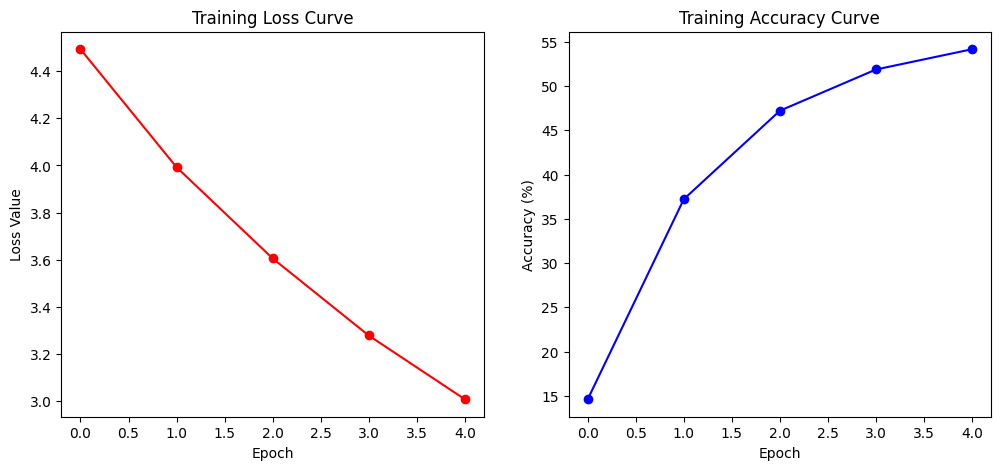

In [ ]:
num_epochs = 5
loss_history = []
acc_history = []

for epoch in range(num_epochs):
    epoch_loss, epoch_acc = train_epoch(dog_model, train_loader, criterion, optimizer, device)
    loss_history.append(epoch_loss)
    acc_history.append(epoch_acc)
    print(f"Epoch {epoch+1}/{num_epochs} Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_history, marker='o', color='red')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')

plt.subplot(1, 2, 2)
plt.plot(acc_history, marker='o', color='blue')
plt.title('Training Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.show()

Iniciar o modelo e wtv
PARA BASELINE

In [ ]:
def initialize_model():
    model = models.resnet50(weights='DEFAULT') # slides dizem para usarmos uma pre treinada ja (semana 4 acho eu)

    for param in model.parameters():
        param.requires_grad = False

    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 120)

    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dog_model = initialize_model().to(device)
criterion = nn.CrossEntropyLoss() # na semana 3 isto é mencionado
optimizer = optim.Adam(dog_model.fc.parameters(), lr=0.0001)

train_set = DogDataset(labels_df, 'train/', transform=baseline_transform)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_hits = 0
    total_samples = 0

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()

        predictions = model(images)
        loss = criterion(predictions, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted_class = predictions.max(1)
        total_samples += targets.size(0)
        correct_hits += predicted_class.eq(targets).sum().item()

    return running_loss / total_samples, 100. * correct_hits / total_samples

num_epochs = 5
loss_history = []
acc_history = []

for epoch in range(num_epochs):
    epoch_loss, epoch_acc = train_epoch(dog_model, train_loader, criterion, optimizer, device)
    loss_history.append(epoch_loss)
    acc_history.append(epoch_acc)
    print(f"Epoch {epoch+1}/{num_epochs} Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_history, marker='o', color='red')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')

plt.subplot(1, 2, 2)
plt.plot(acc_history, marker='o', color='blue')
plt.title('Training Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.show()

outros (cloud fez mas lowkey acho que posso apagar? os que tao em baixo)

Epoch 1/10 Loss: 2.7811 | Accuracy: 56.54%
Epoch 2/10 Loss: 2.5909 | Accuracy: 57.87%
Epoch 3/10 Loss: 2.4454 | Accuracy: 58.77%
Epoch 4/10 Loss: 2.2898 | Accuracy: 59.94%
Epoch 5/10 Loss: 2.1752 | Accuracy: 60.91%
Epoch 6/10 Loss: 2.0662 | Accuracy: 61.66%
Epoch 7/10 Loss: 2.0066 | Accuracy: 61.34%
Epoch 8/10 Loss: 1.9112 | Accuracy: 62.93%
Epoch 9/10 Loss: 1.8610 | Accuracy: 63.00%
Epoch 10/10 Loss: 1.7945 | Accuracy: 63.26%


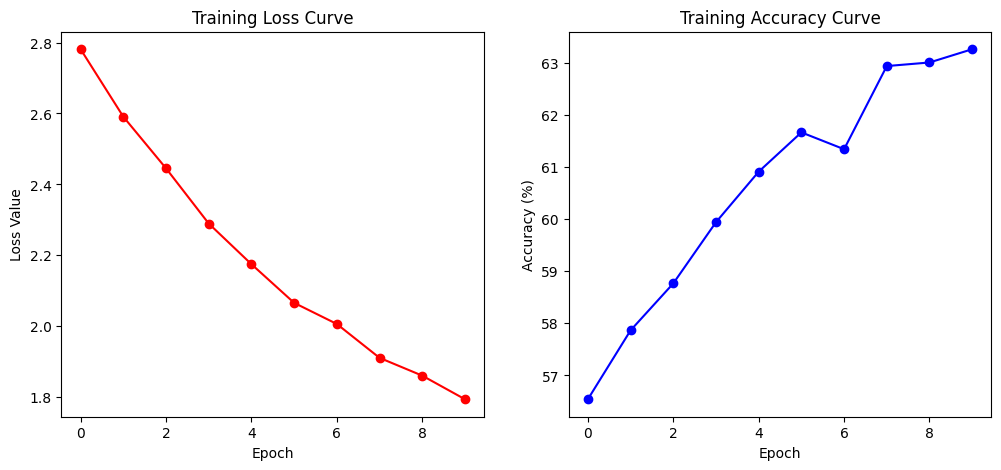

In [ ]:
num_epochs = 10
loss_history = []
acc_history = []

for epoch in range(num_epochs):
    epoch_loss, epoch_acc = train_epoch(dog_model, train_loader, criterion, optimizer, device)
    loss_history.append(epoch_loss)
    acc_history.append(epoch_acc)
    print(f"Epoch {epoch+1}/{num_epochs} Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_history, marker='o', color='red')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')

plt.subplot(1, 2, 2)
plt.plot(acc_history, marker='o', color='blue')
plt.title('Training Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.show()

Epoch 1/5 Loss: 1.7348 | Accuracy: 64.15%
Epoch 2/5 Loss: 1.6762 | Accuracy: 65.13%
Epoch 3/5 Loss: 1.6597 | Accuracy: 64.97%
Epoch 4/5 Loss: 1.6143 | Accuracy: 65.42%
Epoch 5/5 Loss: 1.6162 | Accuracy: 64.82%


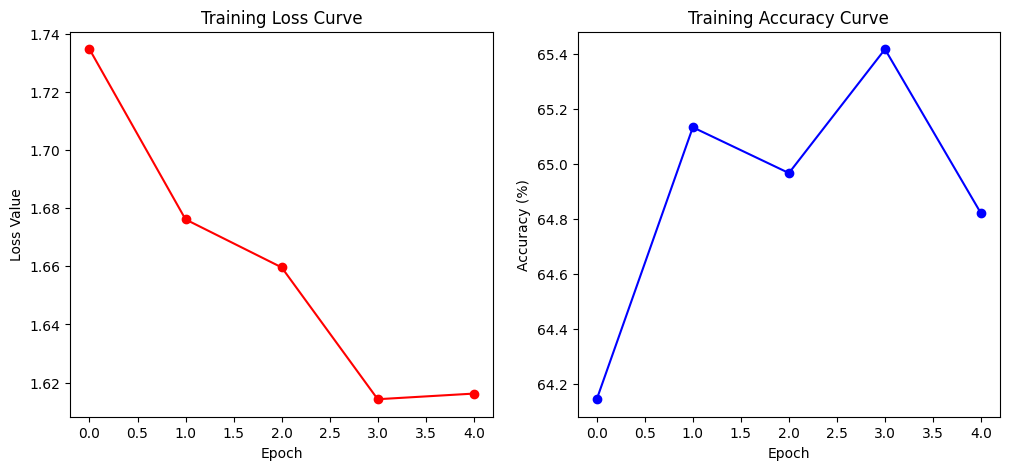

In [ ]:
num_epochs = 5
loss_history = []
acc_history = []

for epoch in range(num_epochs):
    epoch_loss, epoch_acc = train_epoch(dog_model, train_loader, criterion, optimizer, device)
    loss_history.append(epoch_loss)
    acc_history.append(epoch_acc)
    print(f"Epoch {epoch+1}/{num_epochs} Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_history, marker='o', color='red')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')

plt.subplot(1, 2, 2)
plt.plot(acc_history, marker='o', color='blue')
plt.title('Training Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.show()